# tinylm pretrain — analysis

Analysis-only notebook: loads the checkpoint produced by `train.py` (never trains).

- model: `model.py` (~6M GPT: RoPE + QK-norm + ReLU² MLP, FlexAttention doc masking)
- training: `train.py` (raw PyTorch loop; saves to `/mnt/ai/runs/tinylm/pretrain/`)
- results tables: `README.md`

In [1]:
import os

os.environ.setdefault("HF_HOME", "/mnt/ai/data/hf")  # datasets cache

import matplotlib.pyplot as plt
import torch

import train  # project config: model/data/loss definitions (no training on import)
from model import GPT

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE in ("cuda",) else torch.float32

In [2]:
dm = train.make_datamodule()

train_tokens = len(dm.train_dataset.data)
val_tokens = len(dm.val_dataset.data)

print(f"vocab_size={dm.vocab_size}")
print(
    "train mix: "
    + "  ".join(
        f"{k}={v:,} ({v / train_tokens:.0%})" for k, v in dm.source_train_tokens.items()
    )
)
print(
    f"train tokens={train_tokens:,}  val tokens={val_tokens:,}  "
    f"total={train_tokens + val_tokens:,}"
)

vocab_size=16384
train mix: tinystories-v2=500,000,000 (59%)  tiny-textbooks=342,066,330 (41%)
train tokens=842,066,330  val tokens=1,000,000  total=843,066,330


In [ ]:
assert train.CHECKPOINT_PATH.exists(), (
    f"run train.py first: {train.CHECKPOINT_PATH} missing"
)

model = train.make_model(dm.vocab_size)
state = torch.load(train.CHECKPOINT_PATH, map_location="cpu")
# older checkpoints were saved from the torch.compile wrapper -> _orig_mod. prefixes
state = {k.removeprefix("_orig_mod."): v for k, v in state.items()}
model.load_state_dict(state)
model.to(
    DEVICE, dtype=DTYPE
).eval()  # move explicitly — inference on CPU is ~30x slower

total_params = sum(p.numel() for p in model.parameters())
print(f"loaded {train.CHECKPOINT_PATH}  ({total_params:,} params, device={DEVICE})")

loaded /mnt/ai/runs/tinylm/pretrain/chimera_gpt6m.pt  (15,144,192 params, device=cuda)


## Attention masking

Training uses FlexAttention with a causal + document block mask and per-document RoPE
positions (`chimera.models.attention.build_block_mask_and_pos`). The dense reference
masks below are the readable spec of the same rule.

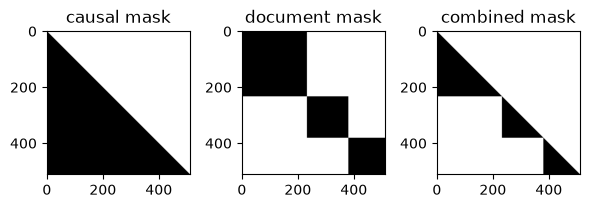

In [4]:
from chimera.models.attention import make_causal_mask, make_document_mask

x, y = next(iter(dm.train_dataloader()))

causal = make_causal_mask(train.SEQ_LEN, device=x.device)  # (1, 1, T, T)
doc = make_document_mask(x, eos_id=dm.eos_id)  # (B, 1, T, T)
attn_mask = causal & doc  # (B, 1, T, T), broadcasts fine

plt.figure(figsize=(6, 6))
plt.subplot(1, 3, 1)
plt.imshow(causal[0, 0].cpu(), cmap="gray_r")
plt.title("causal mask")
plt.subplot(1, 3, 2)
plt.imshow(doc[0, 0].cpu(), cmap="gray_r")
plt.title("document mask")
plt.subplot(1, 3, 3)
plt.imshow(attn_mask[0, 0].cpu(), cmap="gray_r")
plt.title("combined mask")
plt.tight_layout()
plt.show()

## Samples

In [15]:
from textwrap import fill

print(
    fill(
        model.sample(
            dm.tokenizer,
            prompt="Once upon a time",
            eos_token_id=dm.eos_id,
            bos_token_id=dm.bos_id,
            seed=42,
            max_new_tokens=512,
        )  # type: ignore
    )
)

Once upon a time, there was a little girl named Amy. She had a small
garden with many vegetables. One day, she decided to make some
broccoli for her mom's family. Amy asked her mom if they could cook
the broccoli. Her mom said, "Yes, but you need to be careful. If
something is not good, it might get too hot." So, Amy put on her apron
and started to stir the pot. As she stirred, she saw a tiny bird
inside! The bird looked very hungry. The bird flew close to the stove
and touched it. It opened its mouth and said, "Thank you, Amy!" Amy
felt happy that she could help the bird. From that day on, Amy learned
to be more careful with what she cooked. And everyone in the garden
loved her baby.


In [ ]:
print(
    model.sample(
        dm.tokenizer,
        prompt="Lesson: How to grow a tree",
        eos_token_id=dm.eos_id,
        seed=42,
        max_new_tokens=512,
    ),  # type: ignore
)

Lesson: How to grow a tree and plant?
Introduction: A tree is an organism that grows fruits and other natural habitats. It is home to many plant plants, but it can also have different flavor options such as rednessless, blue, and yellow color. In this lesson, we will learn about the different types of trees in nature and how they are grown and why they look good for the environment.
Section 1: Types of Trees
There are several types of trees in nature, including:
1. Monopolysis: This type of tree grows fruit that has a long nose, green eyes, and mouth. It is known for its natural bark and functionality.
2. Harvings: This type of tree grows fruit that has a strong root material, which helps to spread leaves and twigs in their shade.
3. Nausea and white: This type of tree comes from nausea and has a sweet smell that feels soft and soothing on your hair.
Section 2: Distribution of Tree
One of the most important processes of tree growing trees is distribution of tree seeds. These seeds cont

: 

## Zero-shot benchmarks (`lm_eval`)

Zero-shot capability benchmarks via EleutherAI's `lm_eval`. All five are
**loglikelihood-ranking** tasks (score candidate continuations, pick the highest logprob), so we
only expose the model through `lm_eval`'s loglikelihood interface — no generation needed.

Headline metric per task (preference `acc_norm > acc > perplexity`):

| task             | metric              | chance | category             | what it tests                                                                                                                 |
|------------------|---------------------|--------|----------------------|-------------------------------------------------------------------------------------------------------------------------------|
| `blimp`          | `acc`               | 50.0   | short-range grammar  | Two sentences differ by one grammatical feature (agreement, negative polarity, islands); model must favor the grammatical one |
| `lambada_openai` | `acc`, `perplexity` | 0.0    | long-range coherence | Predict the final word of a passage, guessable only from broad discourse context, not local syntax                            |
| `piqa`           | `acc_norm`          | 50.0   | physical commonsense | Given a goal, pick which of two proposed actions actually works physically                                                    |
| `sciq`           | `acc_norm`          | 25.0   | science fact recall  | 4-way multiple choice, elementary/middle-school science questions (physics, chem, bio)                                        |
| `arc_easy`       | `acc_norm`          | 25.0   | science reasoning    | 4-way multiple choice, grade-school science QA (easier split of ARC)                                                          |

At ~2M params / 1000 steps expect everything at/near chance except possibly `blimp` (linguistic
competence, not knowledge — the BabyLM yardstick that moves first). Logged so the trend is visible
as the model scales.

In [12]:
from chimera.evals import ChimeraLM, TASKS, results_table, run_eval

lm = ChimeraLM(
    model,
    dm.tokenizer,
    eot_id=dm.eos_id,
    bos_id=dm.bos_id,
    block_size=model.seq_len,
    device=DEVICE,
    batch_tokens=131072,  # tiny model -> pack big batches for fewer kernel launches
)
results = run_eval(model, lm, TASKS)
display(results_table(results, TASKS))

README.md:   0%|          | 0.00/58.6k [00:00<?, ?B/s]

adjunct_island/train-00000-of-00001.parq(…):   0%|          | 0.00/62.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

anaphor_gender_agreement/train-00000-of-(…):   0%|          | 0.00/39.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

loglikelihood: 100%|██████████| 156330/156330 [00:22<00:00, 6886.21it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:05<00:00, 17.27it/s]


[eval] scored + cached results -> results-7f8a5d1d2852779af9c3ced63bd63899.pkl


,metric,this model,stderr,chance,GPT-2 small (124M)
task,,,,,
blimp,acc,65.03,0.16,50.0,82.29
lambada_openai,acc,12.59,0.46,0.0,32.16
piqa,acc_norm,56.53,1.16,50.0,62.62
sciq,acc_norm,54.70,1.57,25.0,64.40
arc_easy,acc_norm,31.99,0.96,25.0,39.52


Past results (data-mix ablations at 1k iters) live in the [README](README.md).

## Train-step profile

Times the optimized train path (FlexAttention + torch.compile + CCE) on an isolated
copy of the model — never mutates the loaded weights.

In [13]:
from chimera.utils import profile_train_step

profile_train_step(
    model,
    next(iter(dm.train_dataloader())),
    loss_fn=lambda m, bx, by: train.compute_loss(m, bx, by, dm.eos_id, dm.vocab_size),
    make_optimizer=train.make_optimizer,
    loss_label="CutCrossEntropy" if train.USE_CCE else "CrossEntropyLoss",
)

batch (128, 512)  (65,536 tokens)  |  loss: CutCrossEntropy  |  20 iters
------------------------------------------------------------
forward      35.102 ms  (30.9%)
backward     74.912 ms  (65.9%)
optimizer     3.700 ms  ( 3.3%)
------------------------------------------------------------
step total  113.714 ms   ->  576,321 tokens/s
peak memory 5.56 GB


/root/Code/chimera/.venv/lib/python3.13/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-07-19 03:57:27 2900839:2900839 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-19 03:57:27 2900839:2900839 ActivityProfilerController.cpp:455] profiler_stop



-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         1.11%       6.055ms         1.53%       8.372ms      23.255us     194.371ms        36.04%     194.371ms     539.920us           360  
                     LinearCrossEntropyFunctionBackward         0.23%       1.260ms         1.10%       6.042ms       1.208ms     112.895ms        20.93%     113.302ms      22.660ms             5  
        